## Logistic regression

In [3]:
library(tidyverse)

── Attaching core tidyverse packages ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


Here were have collection of logistic regression related code from scratch.

## Logistic function

In [2]:
logistic_fun = function(x){
    return(1 / (1 + exp(-1 * x)))
}

Test the logistic function

In [11]:
x_val = -100:100
y_val = map_dbl(x_val, logistic_fun)
df = data.frame(x = x_val, y = y_val)

In [21]:
lfun.pt = df %>% ggplot(aes(x = x_val, y = y_val)) + geom_line() + theme_bw()

## Logistic regression 

Here we test a simple logistic regression model with one variable.

In [17]:
linear_fun = function(x, w, b){
    # Here w is a the weight vector
    # b is the bias 
    # and x are the input valiues 
    return(w %*% x + b)
}

In [19]:
out_lf = linear_fun(5, -1, 0.5)

We will plug this in to the logistic function to get a value between 0 and 1

In [20]:
logistic_fun(out_lf)

0.01098694


In [22]:
out_lf

-4.5


Warning message in geom_point(aes(x = -4.5, y = logistic_fun(out_lf))):
“All aesthetics have length 1, but the data has 201 rows.
ℹ Please consider using `annotate()` or provide this layer with data containing a single row.”


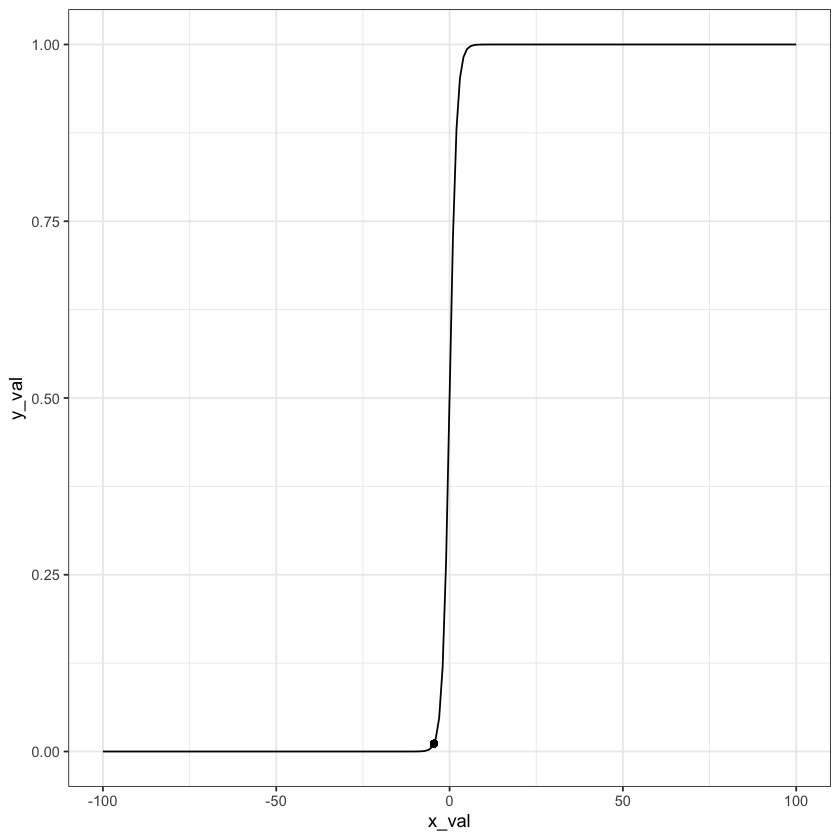

In [23]:
lfun.pt + geom_point(aes(x = -4.5, y = logistic_fun(out_lf)))

## Log-loss for logistic regression

To train the logistic regression model we would need to have a loss function to minimize. Logistic regression uses the logistic log loss which is based on entropy.

In [38]:
one_hot_mat = function(x){
    binary.hot.mat = data.frame("0" = x,
                                "1" = 1 - x)
    binary.hot.mat = as.matrix(binary.hot.mat)
    return(binary.hot.mat)
}

In [41]:
logistic_log_loss = function(y, p){
   
   # Generate a one hot matrix indicating the 
   # true label y 
   one.hot.mat.y =  one_hot_mat(y)
   print(one.hot.mat.y)
    
   # Generate one hot matrix 
   one.hot.mat.p = one_hot_mat(p)
   print(one.hot.mat.p)
   
   # Take the log 
   one.hot.mat.p.log = log(one.hot.mat.p)
    
   # Perform rowise dot product 
   dps = rep(NA, nrow(one.hot.mat.y))
   for (i in 1:nrow(one.hot.mat.y)){
       dp = one.hot.mat.y[i,] %*% one.hot.mat.p.log[i,]
       dps[i] = dp 
   }
   log.loss = sum(dps)/nrow(one.hot.mat.y)
   return(log.loss)
}

In [39]:
one_hot_mat(test)

X0,X1
1,0
0,1
1,0


In [49]:
logistic_log_loss(y = c(1, 0, 1), p = c(0.9, 0.05, 0.99))

     X0 X1
[1,]  1  0
[2,]  0  1
[3,]  1  0
       X0   X1
[1,] 0.90 0.10
[2,] 0.05 0.95
[3,] 0.99 0.01


[1] -0.05556805